In [1]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import math

In [2]:

DATASET="/home/wolverine/open-source/isro/ZERN_Trans_Dataset_500k.h5"
# 1. Open the file and load data into PyTorch tensors
with h5py.File(DATASET, 'r') as f:
    # Print keys to see dataset names
    print("Keys in HDF5 file:", list(f.keys()))
    
    x_data = torch.tensor(f['X_Tokens'][()])
    y_data = torch.tensor(f['Y_Zernikes'][()])
    print(x_data.shape)
    print(y_data.shape)

print("Data loaded successfully as PyTorch Tensors!")


Keys in HDF5 file: ['X_Tokens', 'Y_Zernikes']
torch.Size([100000, 276, 5])
torch.Size([100000, 65])
Data loaded successfully as PyTorch Tensors!


In [3]:
import torch
import torch.nn as nn
import math

# Simulate the data loaded from the HDF5 file
# X_Tokens: (Batch, N, 5) -> N=276 valid sub-apertures, 5 features [Sx, Sy, I, x, y]
# Y_Zernikes: (Batch, 65) -> Assuming 65 output coefficients to match the tensor shape
batch_size = 32  # Reduced batch size for demonstration (originally 100,000)
num_tokens = 276
num_features = 5
out_dim = 65

# Dummy tensors simulating your input
X_tokens = torch.randn(batch_size, num_tokens, num_features)
Y_zernikes = torch.randn(batch_size, out_dim)

print(f"Input Tokens Shape: {X_tokens.shape}")
print(f"Target Zernikes Shape: {Y_zernikes.shape}")

Input Tokens Shape: torch.Size([32, 276, 5])
Target Zernikes Shape: torch.Size([32, 65])


In [13]:
from transformers import AutoProcessor, SiglipVisionModel, SiglipVisionConfig


In [12]:
import torch
import torch.nn as nn

class FeatureEmbedding(nn.Module):
    """Fuses Slopes, Intensity, and Spatial Positions."""
    def __init__(self, d_model=128):
        super().__init__()
        self.slope_proj = nn.Linear(2, d_model)
        self.intensity_proj = nn.Linear(1, d_model)
        self.pos_encoder = nn.Linear(2, d_model)
        self.fuser = nn.Linear(d_model * 3, d_model)  # or just Linear(5, d_model) directly

    def forward(self, x):
        s = self.slope_proj(x[..., 0:2])
        i = self.intensity_proj(x[..., 2:3])
        p = self.pos_encoder(x[..., 3:5])
        return self.fuser(torch.cat([s, i, p], dim=-1))
class SiglipAttentionPooling(nn.Module):
    """
    Multihead Attention Pooling (MAP) Head.
    The true SigLIP method for aggregating spatial tokens.
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        
        # --- THE FIX ---
        # Removed the * 0.02. We WANT this vector to be highly distinct 
        # so it doesn't default to a uniform average mask!
        self.latent_query = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True)
        self.layernorm = nn.LayerNorm(d_model)

    def forward(self, x):
        B = x.size(0)
        
        # Expand latent query to match batch size: (B, 1, d_model)
        q = self.latent_query.expand(B, -1, -1)
        
        # The latent query attends to all 276 sub-aperture tokens
        attn_out, _ = self.mha(query=q, key=x, value=x)
        
        # Add & Norm (Residual connection)
        out = self.layernorm(q + attn_out)
        
        return out.squeeze(1)
class RegressionHead(nn.Module):
    def __init__(self, d_model=128, out_dim=65, dropout=0.0):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),         # single dropout, single GELU
            nn.Linear(d_model * 2, out_dim)
        )
        self._calibrate_output_scale(d_model)

    def _calibrate_output_scale(self, d_model):
        self.eval()
        with torch.no_grad():
            dummy = torch.randn(512, d_model)
            actual_std = self.decoder(dummy).std().item()
        final = [m for m in self.decoder if isinstance(m, nn.Linear)][-1]
        final.weight.data *= (1.0 / (actual_std + 1e-8))
        self.train()

    def forward(self, x):
        return self.decoder(x)
class WavefrontTransformer(nn.Module):
    def __init__(self, d_model=128, n_heads=8, n_layers=2, out_dim=65, num_patches=276):
        super().__init__()
        
        self.embedding = FeatureEmbedding(d_model=d_model)
        
        # 1. Positional Embeddings (Now only 276 patches, no CLS token!)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, d_model) * 0.02)
                
        # 2. Pre-LN Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 4, 
            activation='gelu', 
            batch_first=True,
            norm_first=True 
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # 3. SigLIP Post-Encoder LayerNorm
        self.post_layernorm = nn.LayerNorm(d_model)
        self.pre_head_norm = nn.LayerNorm(d_model)
        # 4. Attention Pooling & Output
        self.attention_pool = SiglipAttentionPooling(d_model=d_model, n_heads=n_heads)
        self.regression_head = RegressionHead(d_model=d_model, out_dim=out_dim)
        
    def forward(self, x):
        # Embed the raw tokens
        x = self.embedding(x)
        
        # Inject positional context directly into the 276 patches
        x = x + self.pos_embedding
        
        # Process through attention blocks
        x = self.transformer_encoder(x)
        
        # Apply SigLIP post-normalization
        x = self.post_layernorm(x)
        
        # Pool the sequence dynamically
        x = x.mean(dim=1)  
        x = self.pre_head_norm(x)
        # Regress to Zernike modes
        return self.regression_head(x)

In [5]:

import torch
from torch.utils.data import Dataset
import h5py

class WavefrontDataset(Dataset):
    def __init__(self, h5_path):
        super().__init__()
        print(f"Loading {h5_path} into memory...")
        with h5py.File(h5_path, 'r') as f:
            x_raw = torch.tensor(f['X_Tokens'][:], dtype=torch.float32)
            y_raw = torch.tensor(f['Y_Zernikes'][:], dtype=torch.float32)
            
        print("Calculating and applying Z-score standardization...")
        
        # --- Target (Y) Standardization ---
        self.y_mean = y_raw.mean(dim=0)
        self.y_std = y_raw.std(dim=0)
        self.y_data = (y_raw - self.y_mean) / (self.y_std + 1e-8) 

        # --- Input (X) Standardization ---
        # Calculate mean/std across all samples and all sub-aperture tokens
        # x_raw shape is (Samples, Tokens, 5_Features)
        self.x_mean = x_raw.mean(dim=(0, 1), keepdim=True)
        self.x_std = x_raw.std(dim=(0, 1), keepdim=True)
        self.x_data = (x_raw - self.x_mean) / (self.x_std + 1e-8)
        print(self.x_mean,self.x_std)
        # Save X stats for your visualization script later!
        torch.save({'mean': self.x_mean, 'std': self.x_std}, 'x_stats.pt')

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        return self.x_data[idx], self.y_data[idx]
# --- Configuration ---
H5_FILE_PATH = DATASET # Replace with your actual file path
BATCH_SIZE = 256                # Large batch size for 100k dataset
VAL_SPLIT = 0.1                    # 10% for validation (10,000 samples)

# --- Setup DataLoaders ---
# In practice, ensure the file exists before running
try:
    full_dataset = WavefrontDataset(H5_FILE_PATH)
    
    val_size = int(len(full_dataset) * VAL_SPLIT)
    train_size = len(full_dataset) - val_size
    
    train_dataset, val_dataset = random_split(
        full_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42) # Reproducibility
    )
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
except FileNotFoundError:
    print("HDF5 file not found. Create dummy dataloaders for testing the loop...")
    # Dummy fallback to ensure the script runs
    from torch.utils.data import TensorDataset
    dummy_x = torch.randn(100000, 276, 5)
    dummy_y = torch.randn(100000, 65)
    full_dataset = TensorDataset(dummy_x, dummy_y)
    train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loading /home/wolverine/open-source/isro/ZERN_Trans_Dataset_500k.h5 into memory...
Calculating and applying Z-score standardization...
tensor([[[ 2.5604e-07, -1.7252e-07,  9.9867e-01, -8.2475e-06,  2.3801e-06]]]) tensor([[[0.0011, 0.0011, 0.4065, 0.4808, 0.4808]]])
Train batches: 352 | Val batches: 40


In [16]:
import torch.optim as optim
from tqdm import tqdm

In [17]:
import torch
import torch.nn as nn

class ZernikeRMSELoss(nn.Module):
    """
    Standard Root Mean Square Error (RMSE) Loss.
    Matches the optimization metric used in ZernikeNet and ISNet.
    """
    def __init__(self, eps=1e-8):
        super().__init__()
        # Epsilon prevents NaN gradients if the error ever reaches exactly 0
        self.eps = eps

    def forward(self, z_pred, z_true):
        # Calculate the Mean Squared Error across all modes and the batch
        mse = torch.mean((z_pred - z_true) ** 2)
        
        # Return the Root Mean Square Error
        return torch.sqrt(mse + self.eps)

In [18]:
import gc
import numpy as np
# 1. Delete old model/optimizer references if they exist from a previous run
try:
    del model
    del optimizer
    del scheduler
    del criterion
    del criterion_physics
except NameError:
    pass # If they don't exist yet, just ignore

# 2. Force Python garbage collection
gc.collect()

# 3. Empty the PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --- Now proceed with your normal initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
# ... [rest of your code] ...

import torch.nn as nn
import torch.optim as optim

# 1. Lower LR and use standard MSE
model = WavefrontTransformer(d_model=128, n_heads=8, n_layers=2, out_dim=65).to(device)
criterion = nn.MSELoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

# 2. Use OneCycleLR for built-in Warmup (Ramps up for 10% of training, then decays)
epochs = 20
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=3e-4, 
    steps_per_epoch=len(train_loader), 
    epochs=epochs,
    pct_start=0.1  # Warmup phase
)

# ... [rest of setup] ...
best_val_loss = float('inf')
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for batch_x, batch_y in pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_x)
        
        # 3. Calculate MSE for Backprop
        mse_loss = criterion(predictions, batch_y)
        mse_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # CRITICAL: OneCycleLR steps every BATCH, not every epoch
        scheduler.step() 
        
        # 4. Report RMSE for your logs
        rmse_val = torch.sqrt(mse_loss).item()
        train_loss += rmse_val * batch_x.size(0)
        pbar.set_postfix({'rmse': f"{rmse_val:.4f}"})
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            
            # Use MSE, log RMSE
            mse_loss = criterion(predictions, batch_y)
            val_loss += torch.sqrt(mse_loss).item() * batch_x.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # Note: Remove scheduler.step() from down here! It moved to the batch loop.
    print(f"Epoch {epoch+1} Summary -> Train RMSE: {train_loss:.5f} | Val RMSE: {val_loss:.5f}")
    # --- Checkpoint Saving ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_wavefront_model.pth")
        print(f"*** New best model saved! (Loss: {best_val_loss:.5f}) ***")

print("Training Complete!")

/tmp/ipykernel_19766/2331422624.py:78: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Training on device: cuda


Epoch 1/20 [Train]: 100%|██████████| 352/352 [01:31<00:00,  3.83it/s, rmse=0.9634]


Epoch 1 Summary -> Train RMSE: 1.00264 | Val RMSE: 1.00166
*** New best model saved! (Loss: 1.00166) ***


Epoch 2/20 [Train]: 100%|██████████| 352/352 [01:25<00:00,  4.14it/s, rmse=0.9504]


Epoch 2 Summary -> Train RMSE: 0.99977 | Val RMSE: 1.00156
*** New best model saved! (Loss: 1.00156) ***


Epoch 3/20 [Train]:  14%|█▍        | 50/352 [00:12<01:14,  4.05it/s, rmse=1.0212]


KeyboardInterrupt: 

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

print("--- STARTING SINGLE BATCH OVERFIT TEST ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize a fresh, untrained model
test_loader_iter = iter(train_loader)
batch_x, batch_y = next(test_loader_iter)
batch_x, batch_y = batch_x.to(device), batch_y.to(device)

test_model = WavefrontTransformer(d_model=128, n_heads=8, n_layers=2, out_dim=65).to(device)
with torch.no_grad():
    init_std = test_model(batch_x).std().item()
print(f"Init output std: {init_std:.4f}")
assert init_std > 0.6, f"Init still wrong: {init_std:.4f}"

# 2. Use a much more aggressive learning rate for this test
test_optimizer = optim.Adam(test_model.parameters(), lr=5e-2)
test_criterion = nn.MSELoss().to(device)

# 3. Grab EXACTLY ONE batch of data


# 4. Train on this same batch 100 times
test_model.train()
for step in range(101):
    test_optimizer.zero_grad()
  
    preds = test_model(batch_x)
    loss = test_criterion(preds, batch_y)
    
    loss.backward()
    if step % 10 == 0:
        print("\n--- GRADIENT FLOW REPORT ---")
        for name, p in test_model.named_parameters():
            if p.grad is None:
                print(f"  [NO GRAD]  {name}")
            elif p.grad.norm().item() < 1e-7:
                print(f"  [DEAD ~0]  {name}  grad_norm={p.grad.norm().item():.2e}")
            else:
                print(f"  [OK]       {name}  grad_norm={p.grad.norm().item():.4f}")

        print("\n--- OUTPUT DISTRIBUTION ---")
        with torch.no_grad():
            pred = test_model(batch_x)
            print(f"  pred  | mean={pred.mean():.4f}  std={pred.std():.4f}  "
                f"min={pred.min():.4f}  max={pred.max():.4f}")
            print(f"  target| mean={batch_y.mean():.4f}  std={batch_y.std():.4f}")
    test_optimizer.step()
    
    if step % 10 == 0:
        print(f"Step {step:03d} | MSE Loss: {loss.item():.5f}")

print("--- TEST COMPLETE ---")

--- STARTING SINGLE BATCH OVERFIT TEST ---
Init output std: 1.1709

--- GRADIENT FLOW REPORT ---


/tmp/ipykernel_26609/2703049607.py:87: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  [OK]       pos_embedding  grad_norm=0.1060
  [OK]       embedding.slope_proj.weight  grad_norm=0.0803
  [OK]       embedding.slope_proj.bias  grad_norm=0.5851
  [OK]       embedding.intensity_proj.weight  grad_norm=0.0637
  [OK]       embedding.intensity_proj.bias  grad_norm=0.6136
  [OK]       embedding.pos_encoder.weight  grad_norm=0.1081
  [OK]       embedding.pos_encoder.bias  grad_norm=0.6098
  [OK]       embedding.fuser.weight  grad_norm=15.3939
  [OK]       embedding.fuser.bias  grad_norm=1.7294
  [OK]       transformer_encoder.layers.0.self_attn.in_proj_weight  grad_norm=4.4064
  [OK]       transformer_encoder.layers.0.self_attn.in_proj_bias  grad_norm=0.5984
  [OK]       transformer_encoder.layers.0.self_attn.out_proj.weight  grad_norm=4.9377
  [OK]       transformer_encoder.layers.0.self_attn.out_proj.bias  grad_norm=0.9656
  [OK]       transformer_encoder.layers.0.linear1.weight  grad_norm=2.5246
  [OK]       transformer_encoder.layers.0.linear1.bias  grad_norm=0.2975
  [O

In [9]:

print("--- STARTING SINGLE BATCH OVERFIT TEST ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize a fresh, untrained model
test_loader_iter = iter(train_loader)
batch_x, batch_y = next(test_loader_iter)
batch_x, batch_y = batch_x.to(device), batch_y.to(device)

model = WavefrontTransformer(d_model=128, n_heads=8, n_layers=2, out_dim=65).to(device)
model.eval()

stds = {}
hooks = []

def make_hook(name):
    def hook(module, inp, out):
        t = out[0] if isinstance(out, tuple) else out
        stds[name] = t.detach().float().std().item()
    return hook

hooks.append(model.embedding.register_forward_hook(make_hook("1_embedding_out")))
hooks.append(model.transformer_encoder.register_forward_hook(make_hook("2_encoder_out")))
hooks.append(model.post_layernorm.register_forward_hook(make_hook("3_post_ln_out")))
hooks.append(model.attention_pool.mha.register_forward_hook(make_hook("4_mha_out_raw")))
hooks.append(model.attention_pool.layernorm.register_forward_hook(make_hook("5_map_ln_out")))
hooks.append(model.regression_head.decoder[0].register_forward_hook(make_hook("6_head_linear1")))
hooks.append(model.regression_head.decoder[-1].register_forward_hook(make_hook("7_head_linear2")))

with torch.no_grad():
    out = model(batch_x)

for h in hooks:
    h.remove()

print("\n--- FORWARD PASS STD TRACE ---")
for name, std in stds.items():
    flag = " ← COLLAPSE" if std < 0.1 else ""
    print(f"  {name:35s} std={std:.4f}{flag}")

print(f"\n  {'final output':35s} std={out.std():.4f}")

# Also verify calibration actually ran
final_w = [m for m in model.regression_head.decoder if isinstance(m, nn.Linear)][-1].weight
print(f"\n  final_linear weight std: {final_w.std():.4f}")
print(f"  (Kaiming default for Linear(256,65) ≈ 0.056)")
print(f"  (If still 0.056, calibration DID NOT RUN on this instance)")

--- STARTING SINGLE BATCH OVERFIT TEST ---

--- FORWARD PASS STD TRACE ---
  1_embedding_out                     std=0.4709
  2_encoder_out                       std=0.7764
  3_post_ln_out                       std=1.0000
  4_mha_out_raw                       std=0.3610
  5_map_ln_out                        std=1.0000
  6_head_linear1                      std=0.5454
  7_head_linear2                      std=0.8724

  final output                        std=0.8724

  final_linear weight std: 0.1793
  (Kaiming default for Linear(256,65) ≈ 0.056)
  (If still 0.056, calibration DID NOT RUN on this instance)


/tmp/ipykernel_26609/4253486013.py:87: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


/tmp/ipykernel_19766/2331422624.py:78: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Raw Scaled Prediction: [-0.00401706 -0.02927123  0.00067144 -0.01612134 -0.01795711]
Is Prediction NaN? False


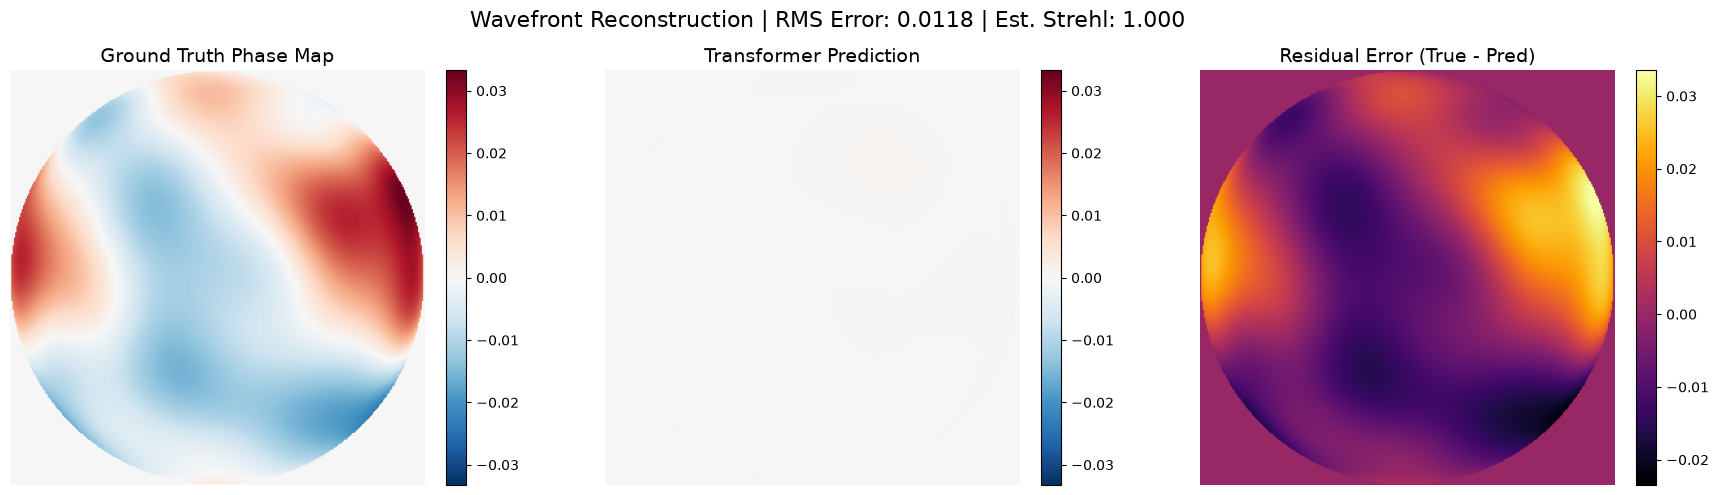

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 1. Load the Best Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the architecture (must match training exactly)
eval_model = WavefrontTransformer(d_model=128, n_heads=8, n_layers=2, out_dim=65).to(device)

# Load the saved weights
eval_model.load_state_dict(torch.load("best_wavefront_model.pth", map_location=device))
eval_model.eval() # CRITICAL: Turn off dropout for inference

# --- 2. Grab a Random Sample ---
# Using val_dataset from Cell 6 to ensure it's data the model hasn't trained on
sample_idx = random.randint(0, len(val_dataset) - 1)
x_sample, y_true = val_dataset[sample_idx]

# Add a batch dimension: (276, 5) -> (1, 276, 5)
x_input = x_sample.unsqueeze(0).to(device)

# --- 3. Run Inference ---
# --- 3. Run Inference ---
# Load the stats we saved earlier
stats = torch.load('zernike_stats.pt', map_location=device)
y_mean = stats['mean'].cpu().numpy()
y_std = stats['std'].cpu().numpy()

with torch.no_grad():
    # The raw output from the network (Z-scored)
    y_pred_scaled = eval_model(x_input).squeeze(0).cpu().numpy()
    
    # Reverse the standardization: X = (Z * Std) + Mean
    y_pred = (y_pred_scaled * y_std) + y_mean
    
# We also need to un-scale y_true for an apples-to-apples comparison
y_true = (y_true.numpy() * y_std) + y_mean
# --- ADD THESE TWO LINES ---
print("Raw Scaled Prediction:", y_pred_scaled[:5]) 
print("Is Prediction NaN?", np.isnan(y_pred_scaled).any())
grid_res = 320 # <--- Updated to match your HCIPy generation script (20 * 16)

# Load the real Zernike polynomials you just generated
zernike_basis = np.load("my_real_zernike_basis_cube.npy")
# --- 4. Reconstruct the 2D Phase Maps ---
# Note: In your actual code, load your real 3D Zernike basis cube here. 
# Shape should be (65_modes, resolution, resolution).
x = np.linspace(-1, 1, grid_res)
y = np.linspace(-1, 1, grid_res)
xx, yy = np.meshgrid(x, y)
pupil_mask = (xx**2 + yy**2) <= 1.0

# Apply mask to the basis to ensure the outside is strictly zero
zernike_basis = zernike_basis * pupil_mask

# Reconstruct: Phase(x,y) = Sum[ Z_i * Basis_i(x,y) ]
true_phase_map = np.tensordot(y_true, zernike_basis, axes=([0], [0]))
pred_phase_map = np.tensordot(y_pred, zernike_basis, axes=([0], [0]))

# Calculate the Residual (Phase Error)
residual_map = true_phase_map - pred_phase_map

# --- 5. Calculate Physical Metrics ---
# Root Mean Square Wavefront Error (RMS WFE) in the valid pupil area
variance = np.var(residual_map[pupil_mask])
rms_wfe = np.sqrt(variance)

# Approximate Strehl Ratio using the Maréchal approximation (S ≈ e^(-variance))
# This perfectly ties back to your Spatial Phase Loss justification!
strehl_ratio = np.exp(-variance)

# --- 6. Plot the Results ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle(f"Wavefront Reconstruction | RMS Error: {rms_wfe:.4f} | Est. Strehl: {strehl_ratio:.3f}", fontsize=16)

# Find absolute max for consistent colorbar scaling across all plots
vmax = max(np.max(np.abs(true_phase_map)), np.max(np.abs(pred_phase_map)))
vmin = -vmax

# Ground Truth Plot
im0 = axes[0].imshow(true_phase_map, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[0].set_title("Ground Truth Phase Map", fontsize=14)
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Prediction Plot
im1 = axes[1].imshow(pred_phase_map, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[1].set_title("Transformer Prediction", fontsize=14)
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Residual Plot
im2 = axes[2].imshow(residual_map, cmap='inferno')
axes[2].set_title("Residual Error (True - Pred)", fontsize=14)
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()